## 1. Carga y preparación de datos


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



# Cargar el dataset
RRHH = pd.read_csv(r"C:\Users\nuez_\Desktop\Proyecto\ProjecteData\Equip_24\Data\clean_RRHH_10032026.csv")

In [38]:
RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours,Reason_Description
0,14,11,11,Monday,Spring,155,12,14,34,284.031,...,High School,2,True,False,0,95,196,25,120,Digestive system diseases
1,36,13,4,Wednesday,Winter,118,13,18,50,239.409,...,High School,1,True,False,0,98,178,31,120,Musculoskeletal/Connective tissue
2,9,6,7,Tuesday,Summer,228,14,16,58,264.604,...,High School,2,False,False,1,65,172,22,120,Nervous system diseases
3,28,9,7,Tuesday,Summer,225,26,9,28,230.290,...,High School,1,False,False,2,69,169,24,112,Circulatory system diseases
4,9,12,3,Tuesday,Autumn,228,14,16,58,222.196,...,High School,2,False,False,1,65,172,22,112,Skin/Subcutaneous diseases
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801,132,11,6,Friday,Winter,179,51,18,38,377.550,...,High School,0,True,False,0,89,170,31,2,Digestive system diseases
802,133,10,5,Friday,Winter,155,12,14,34,237.656,...,High School,2,True,False,0,95,196,25,8,Respiratory system diseases
803,134,10,11,Wednesday,Spring,260,50,11,36,284.031,...,High School,4,True,False,0,65,168,23,8,Respiratory system diseases
804,135,28,10,Tuesday,Spring,225,26,9,28,253.465,...,High School,1,False,False,2,69,169,24,2,Dental consultation


In [39]:
RRHH = RRHH.drop(columns=['Weight', 'Height'])

In [40]:
RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Body_mass_index,Absenteeism_hours,Reason_Description
0,14,11,11,Monday,Spring,155,12,14,34,284.031,97,0,High School,2,True,False,0,25,120,Digestive system diseases
1,36,13,4,Wednesday,Winter,118,13,18,50,239.409,98,0,High School,1,True,False,0,31,120,Musculoskeletal/Connective tissue
2,9,6,7,Tuesday,Summer,228,14,16,58,264.604,93,0,High School,2,False,False,1,22,120,Nervous system diseases
3,28,9,7,Tuesday,Summer,225,26,9,28,230.290,92,0,High School,1,False,False,2,24,112,Circulatory system diseases
4,9,12,3,Tuesday,Autumn,228,14,16,58,222.196,99,0,High School,2,False,False,1,22,112,Skin/Subcutaneous diseases
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801,132,11,6,Friday,Winter,179,51,18,38,377.550,94,0,High School,0,True,False,0,31,2,Digestive system diseases
802,133,10,5,Friday,Winter,155,12,14,34,237.656,99,0,High School,2,True,False,0,25,8,Respiratory system diseases
803,134,10,11,Wednesday,Spring,260,50,11,36,284.031,97,0,High School,4,True,False,0,23,8,Respiratory system diseases
804,135,28,10,Tuesday,Spring,225,26,9,28,253.465,93,0,High School,1,False,False,2,24,2,Dental consultation


## 2. Creación de la variable objetivo

In [41]:
RRHH["Absenteeism_level"] = pd.cut(
    RRHH["Absenteeism_hours"],
    bins=[-1, 4, 16, float("inf")],
    labels=["baja", "media", "alta"]
)

RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Body_mass_index,Absenteeism_hours,Reason_Description,Absenteeism_level
0,14,11,11,Monday,Spring,155,12,14,34,284.031,...,0,High School,2,True,False,0,25,120,Digestive system diseases,alta
1,36,13,4,Wednesday,Winter,118,13,18,50,239.409,...,0,High School,1,True,False,0,31,120,Musculoskeletal/Connective tissue,alta
2,9,6,7,Tuesday,Summer,228,14,16,58,264.604,...,0,High School,2,False,False,1,22,120,Nervous system diseases,alta
3,28,9,7,Tuesday,Summer,225,26,9,28,230.290,...,0,High School,1,False,False,2,24,112,Circulatory system diseases,alta
4,9,12,3,Tuesday,Autumn,228,14,16,58,222.196,...,0,High School,2,False,False,1,22,112,Skin/Subcutaneous diseases,alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801,132,11,6,Friday,Winter,179,51,18,38,377.550,...,0,High School,0,True,False,0,31,2,Digestive system diseases,baja
802,133,10,5,Friday,Winter,155,12,14,34,237.656,...,0,High School,2,True,False,0,25,8,Respiratory system diseases,media
803,134,10,11,Wednesday,Spring,260,50,11,36,284.031,...,0,High School,4,True,False,0,23,8,Respiratory system diseases,media
804,135,28,10,Tuesday,Spring,225,26,9,28,253.465,...,0,High School,1,False,False,2,24,2,Dental consultation,baja


La variable **Absenteeism_hours** contiene las horas de ausencia de cada empleado. Para responder la pregunta de negocio necesitamos transformarla en una variable categórica con tres niveles de riesgo:

| Nivel | Horas de ausencia | Interpretación |
|-------|------------------|----------------|
| **Baja** | 0 - 4 horas | Ausencias puntuales sin impacto significativo |
| **Media** | 5 - 16 horas | Ausencias moderadas que requieren seguimiento |
| **Alta** | Más de 16 horas | Ausencias graves que impactan la operativa |

Esta clasificación fue definida con criterio propio basado en jornadas laborales. Como mejora futura se recomienda validar estos umbrales directamente con el departamento de RRHH.

In [42]:
# Distribución de los niveles de absentismo
print(RRHH['Absenteeism_level'].value_counts())

Absenteeism_level
baja     483
media    271
alta      52
Name: count, dtype: int64


## 3. Modelo de regresión logística

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = RRHH[[
    "Age",
    "Distance_Residence_Work",
    "Service_time",
    "Body_mass_index",
    "Work_load_Average_day",
    "Transportation_expense",
    "Son",
    "Pet",
    "Social_drinker",
    "Social_smoker"
]]

y = RRHH["Absenteeism_level"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=5000)
model.fit(X_scaled, y)

coef = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": model.coef_[0]
})

personales = ["Age", "Body_mass_index", "Son", "Pet", "Social_drinker", "Social_smoker"]
laborales = ["Distance_Residence_Work", "Service_time", "Work_load_Average_day", "Transportation_expense"]

coef_personales = coef[coef["Variable"].isin(personales)].sort_values('Coeficiente', ascending=False)
coef_laborales = coef[coef["Variable"].isin(laborales)].sort_values('Coeficiente', ascending=False)

print("VARIABLES PERSONALES")
print(coef_personales)
print("\nVARIABLES LABORALES")
print(coef_laborales)

VARIABLES PERSONALES
          Variable  Coeficiente
8   Social_drinker     0.443881
0              Age     0.035733
6              Son    -0.008051
7              Pet    -0.101879
9    Social_smoker    -0.208862
3  Body_mass_index    -0.286979

VARIABLES LABORALES
                  Variable  Coeficiente
4    Work_load_Average_day     0.172556
2             Service_time     0.113030
5   Transportation_expense    -0.003564
1  Distance_Residence_Work    -0.304309


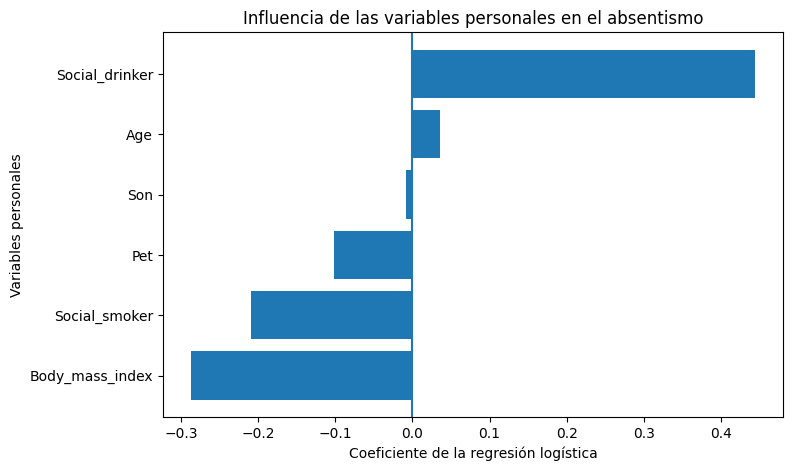

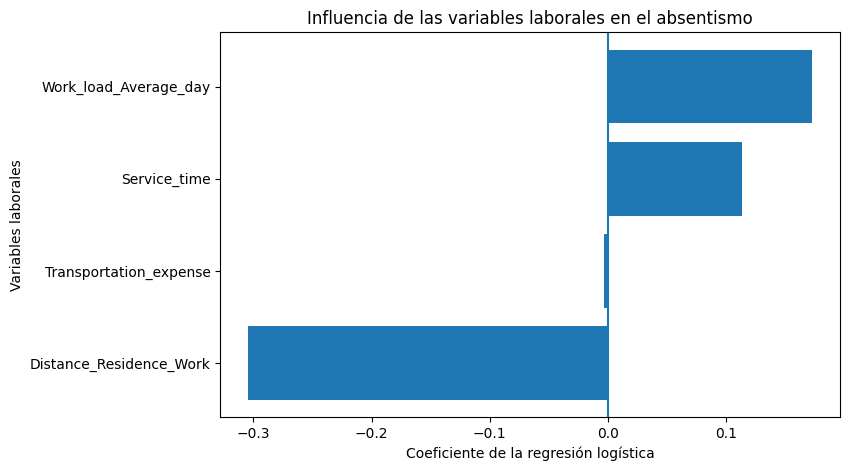

In [44]:
import matplotlib.pyplot as plt

#variables personales
personales = [
    "Age",
    "Body_mass_index",
    "Son",
    "Pet",
    "Social_drinker",
    "Social_smoker"
]

#variables laborales
laborales = [
    "Distance_Residence_Work",
    "Service_time",
    "Work_load_Average_day",
    "Transportation_expense"
]

#separar tablas
coef_personales = coef[coef["Variable"].isin(personales)].sort_values(by="Coeficiente")
coef_laborales = coef[coef["Variable"].isin(laborales)].sort_values(by="Coeficiente")


#---------- gráfico variables personales ----------
plt.figure(figsize=(8,5))
plt.barh(coef_personales["Variable"], coef_personales["Coeficiente"])

plt.axvline(0)
plt.title("Influencia de las variables personales en el absentismo")
plt.xlabel("Coeficiente de la regresión logística")
plt.ylabel("Variables personales")

plt.show()


#---------- gráfico variables laborales ----------
plt.figure(figsize=(8,5))
plt.barh(coef_laborales["Variable"], coef_laborales["Coeficiente"])

plt.axvline(0)
plt.title("Influencia de las variables laborales en el absentismo")
plt.xlabel("Coeficiente de la regresión logística")
plt.ylabel("Variables laborales")

plt.show()

## 4. Significancia estadística y variables clave

In [45]:
import statsmodels.api as sm
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Usamos statsmodels para obtener los p-valores y verificar 
# qué variables son estadísticamente significativas (p < 0.05)

y_num = pd.Categorical(y).codes
X_num = X.astype(float)

X_sm = sm.add_constant(X_num)
modelo_sm = sm.MNLogit(y_num, X_sm)
resultado = modelo_sm.fit()
print(resultado.summary())

Optimization terminated successfully.
         Current function value: 0.791132
         Iterations 7
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                  806
Model:                        MNLogit   Df Residuals:                      784
Method:                           MLE   Df Model:                           20
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.06944
Time:                        19:11:52   Log-Likelihood:                -637.65
converged:                       True   LL-Null:                       -685.23
Covariance Type:            nonrobust   LLR p-value:                 9.161e-12
                    y=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.1354      0.949     -3.304      0.001      -4.995   

- Hasta ahora el modelo nos ha dado los coeficientes de todas las variables pero no sabemos si su efecto es real o producto del azar. Para verificarlo usamos **statsmodels** que nos proporciona los **p-valores** de cada variable.

- Una variable es estadísticamente significativa cuando su **p-valor es menor de 0.05**, lo que significa que hay menos de un 5% de probabilidad de que su efecto sea producto del azar.

In [75]:
# Extraer solo los resultados de y=2 (absentismo alto)
resultados_alto = resultado.summary2().tables[2]
print("ABSENTISMO ALTO (y=2)")
print(resultados_alto.to_string())

ABSENTISMO ALTO (y=2)
                                           y = 1     Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
const                                      const -3.251429  1.897023 -1.713964  0.086535 -6.969525  0.466668
Age                                          Age -0.002590  0.034295 -0.075526  0.939796 -0.069807  0.064626
Distance_Residence_Work  Distance_Residence_Work -0.038831  0.012401 -3.131156  0.001741 -0.063137 -0.014524
Service_time                        Service_time  0.028002  0.074678  0.374974  0.707680 -0.118364  0.174369
Body_mass_index                  Body_mass_index -0.079590  0.046340 -1.717521  0.085884 -0.170414  0.011235
Work_load_Average_day      Work_load_Average_day  0.008155  0.003490  2.336491  0.019466  0.001314  0.014996
Transportation_expense    Transportation_expense  0.003499  0.002755  1.270246  0.203997 -0.001900  0.008898
Son                                          Son  0.035093  0.144356  0.243098  0.807930 -0.247840  0.3180

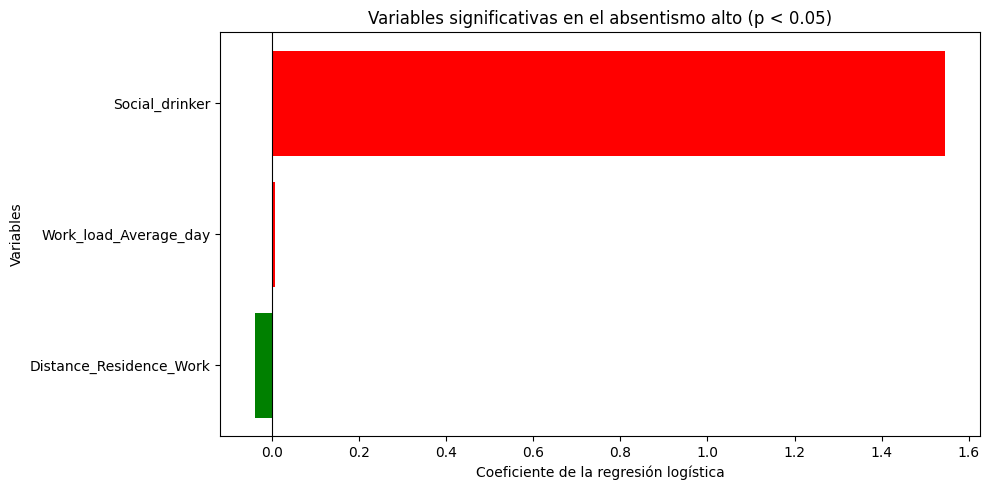

In [72]:
import matplotlib.pyplot as plt

# Solo variables significativas para absentismo alto (p < 0.05)
vars_significativas = {
    'Social_drinker': 1.5460,
    'Distance_Residence_Work': -0.0388,
    'Work_load_Average_day': 0.0082
}

coef_sig = pd.DataFrame({
    'Variable': vars_significativas.keys(),
    'Coeficiente': vars_significativas.values()
}).sort_values('Coeficiente', ascending=True)

colors = ['green' if c < 0 else 'red' for c in coef_sig['Coeficiente']]

plt.figure(figsize=(10, 5))
plt.barh(coef_sig['Variable'], coef_sig['Coeficiente'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Variables significativas en el absentismo alto (p < 0.05)')
plt.xlabel('Coeficiente de la regresión logística')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

El gráfico muestra las **3 variables estadísticamente significativas** (p < 0.05) para predecir el absentismo alto:

- 🔴 **Rojo**: la variable **aumenta** el riesgo de absentismo alto
- 🟢 **Verde**: la variable **reduce** el riesgo de absentismo alto

**Social_drinker** es la variable con mayor impacto, seguida de **Distance_Residence_Work** y **Work_load_Average_day**.

## 5. Perfil de riesgo y evaluación del modelo

In [10]:
perfil_riesgo = RRHH[
    (RRHH['Social_drinker'] == 1) & 
    (RRHH['Work_load_Average_day'] > RRHH['Work_load_Average_day'].median()) &
    (RRHH['Distance_Residence_Work'] < RRHH['Distance_Residence_Work'].median())
]
print(f"Empleados con perfil de riesgo: {len(perfil_riesgo)}")
print(perfil_riesgo['Absenteeism_level'].value_counts())

Empleados con perfil de riesgo: 85
Absenteeism_level
baja     35
media    35
alta     15
Name: count, dtype: int64


In [11]:
# Análisis Social_drinker
print("SOCIAL DRINKER")
print(RRHH.groupby('Social_drinker')['Absenteeism_level'].value_counts(normalize=True).unstack())

print("\nWORK LOAD AVERAGE DAY")
# Dividir en alta y baja carga de trabajo usando la mediana
RRHH['carga_trabajo'] = RRHH['Work_load_Average_day'].apply(
    lambda x: 'Alta' if x > RRHH['Work_load_Average_day'].median() else 'Baja'
)
print(RRHH.groupby('carga_trabajo')['Absenteeism_level'].value_counts(normalize=True).unstack())

print("\nDISTANCE RESIDENCE WORK")
# Dividir en cerca y lejos usando la mediana
RRHH['distancia'] = RRHH['Distance_Residence_Work'].apply(
    lambda x: 'Cerca' if x < RRHH['Distance_Residence_Work'].median() else 'Lejos'
)
print(RRHH.groupby('distancia')['Absenteeism_level'].value_counts(normalize=True).unstack())

SOCIAL DRINKER
Absenteeism_level      baja     media      alta
Social_drinker                                 
False              0.659942  0.308357  0.031700
True               0.553377  0.357298  0.089325

WORK LOAD AVERAGE DAY
Absenteeism_level      baja     media      alta
carga_trabajo                                  
Alta               0.560794  0.354839  0.084367
Baja               0.637717  0.317618  0.044665

DISTANCE RESIDENCE WORK
Absenteeism_level      baja     media      alta
distancia                                      
Cerca              0.550296  0.363905  0.085799
Lejos              0.634615  0.316239  0.049145


MÉTRICAS MODELO ORIGINAL
              precision    recall  f1-score   support

        alta       0.00      0.00      0.00        52
        baja       0.67      0.91      0.77       483
       media       0.63      0.34      0.44       271

    accuracy                           0.66       806
   macro avg       0.43      0.42      0.40       806
weighted avg       0.61      0.66      0.61       806



c:\Users\nuez_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nuez_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nuez_\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

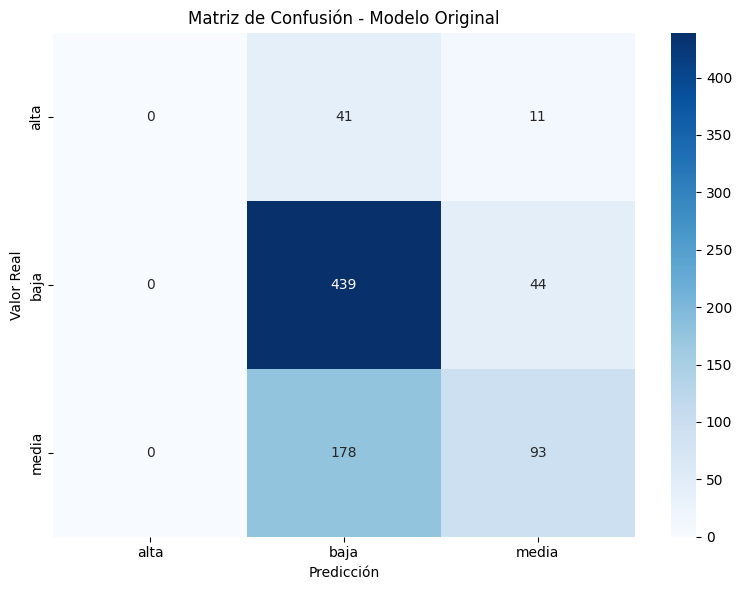

In [47]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ---- MODELO ORIGINAL ----
y_pred = model.predict(X_scaled)

print("MÉTRICAS MODELO ORIGINAL")
print(classification_report(y, y_pred))

cm1 = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['alta', 'baja', 'media'],
            yticklabels=['alta', 'baja', 'media'])
plt.title('Matriz de Confusión - Modelo Original')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

### Matriz de Confusión - Modelo Original

El modelo original **no detecta ningún caso de absentismo alto** (columna alta = 0 en toda la diagonal). De los 52 casos reales de absentismo alto:

- 41 los clasifica como **baja** ❌
- 11 los clasifica como **media** ❌
- 0 los identifica correctamente como **alta** ❌

Esto se debe al **desbalance de clases**: el modelo tiene 483 ejemplos de absentismo bajo y solo 52 de alto, por lo que aprende a ignorar la clase minoritaria. Para solucionar esto aplicamos `class_weight='balanced'` en el siguiente bloque.

MÉTRICAS MODELO BALANCED
              precision    recall  f1-score   support

        alta       0.15      0.56      0.23        52
        baja       0.72      0.53      0.61       483
       media       0.51      0.48      0.50       271

    accuracy                           0.51       806
   macro avg       0.46      0.52      0.45       806
weighted avg       0.62      0.51      0.55       806



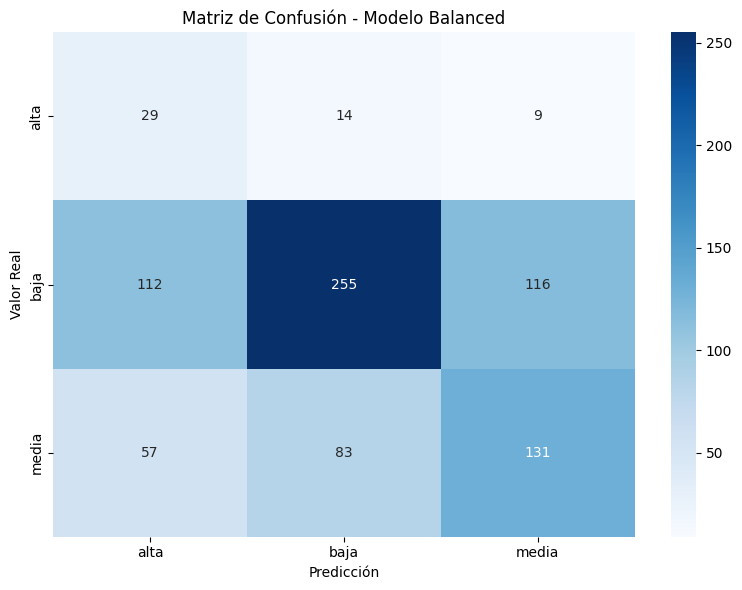

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

# ---- MODELO BALANCED ----
model_balanced = LogisticRegression(max_iter=5000, class_weight='balanced')
model_balanced.fit(X_scaled, y)
y_pred_balanced = model_balanced.predict(X_scaled)

print("MÉTRICAS MODELO BALANCED")
print(classification_report(y, y_pred_balanced))

cm2 = confusion_matrix(y, y_pred_balanced)
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['alta', 'baja', 'media'],
            yticklabels=['alta', 'baja', 'media'])
plt.title('Matriz de Confusión - Modelo Balanced')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

### Matriz de Confusión - Modelo Balanced

Al aplicar `class_weight='balanced'` el modelo ahora **sí detecta casos de absentismo alto**. De los 52 casos reales de absentismo alto:

- 29 los identifica correctamente como **alta** ✅ (56%)
- 14 los clasifica como **baja** ❌
- 9 los clasifica como **media** ❌

El coste de esta mejora es que el modelo genera más **falsas alarmas** en la clase baja, clasificando 112 empleados de absentismo bajo como alto. Sin embargo para el objetivo de negocio es preferible detectar el mayor número posible de empleados de riesgo alto aunque se generen algunas falsas alarmas, ya que RRHH puede filtrarlas con criterio humano.